# Bulk ATAC footprinting — TF activity from Tn5 cut profiles

A transcription factor bound to DNA shields its motif from Tn5, leaving a **footprint** — a local
dip in ATAC-seq cut density flanked by hypersensitive edges. `ov.epi` wraps epione's TOBIAS-style
footprinting so you can correct Tn5 sequence bias, score footprints, and find **differentially
bound** TFs between conditions.

**Data.** The TOBIAS 2020 reference: bulk ATAC-seq of **B cells vs. T cells** (a chr4 subset), with
BAMs, a merged peak set, a JASPAR motif file, and precomputed footprint bigwigs. Point `DATA` at
your copy.

> **Note.** Footprinting uses epione's compiled Cython kernels (`signals` / `sequences`). If
> `import` fails on your platform, rebuild them once with `python build_cython.py` from the epione
> source tree.

1. correct Tn5 bias (`ov.epi.tl.atacorrect`)
2. browse corrected + footprint tracks (`ov.epi.bulk.bigwig`)
3. differential TF binding B cell vs. T cell (`ov.epi.tl.bindetect`)
4. aggregate footprint at a TF's sites (`ov.epi.tl.plot_aggregate`)

In [1]:
import pathlib, warnings
warnings.filterwarnings('ignore')
import pandas as pd
import matplotlib.pyplot as plt
import omicverse as ov
ov.epi.pl.plot_set()
print('omicverse', ov.__version__)

DATA = pathlib.Path('/scratch/users/steorra/data/tobias-2020')
OUT = pathlib.Path.cwd() / 'data_epi' / 'footprint'
OUT.mkdir(parents=True, exist_ok=True)
for must in ['Bcell.bam', 'Tcell.bam', 'genome.fa', 'merged_peaks.bed', 'motifs.jaspar',
             'Bcell_footprints.bw', 'Tcell_footprints.bw', 'merged_peaks_annotated.bed', 'BATF_all.bed']:
    assert (DATA / must).exists(), f'missing {DATA/must}'
print('data ready')

└─ 🔬 Starting plot initialization...
  ├─ Apply Scanpy/matplotlib settings
  ├─ Custom font setup
  ├─ Suppress warnings
  ├─ 
___________      .__                      
\_   _____/_____ |__| ____   ____   ____  
 |    __)_\____ \|  |/  _ \ /    \_/ __ \ 
 |        \  |_> >  (  <_> )   |  \  ___/ 
/_______  /   __/|__|\____/|___|  /\___  >
        \/|__|                  \/     \/ 

  ├─ 🔖 Version: 0.0.1rc1   📚 Tutorials: https://epione.readthedocs.io/
└─ ✅ plot_set complete.

omicverse 2.2.1rc1
data ready


## 1 · Tn5 bias correction

`ov.epi.tl.atacorrect` learns the Tn5 insertion-bias model from the BAM + genome and writes a
**bias-corrected** coverage bigwig per condition (the ATAC analogue of input-normalisation).

In [2]:
for cond in ['Bcell', 'Tcell']:
    ov.epi.tl.atacorrect(
        bam_file=str(DATA / f'{cond}.bam'), fasta_file=str(DATA / 'genome.fa'),
        peak_bed_file=str(DATA / 'merged_peaks.bed'),
        output_prefix=str(OUT / cond), k_flank=12, score_mat='DWM', verbose=False)
print('corrected tracks:', sorted(p.name for p in OUT.glob('*_corrected.bw')))

Saved /scratch/users/steorra/analysis/omicverse_dev/guide-upstream-wt/docs/Tutorials-epigenetics/data_epi/footprint/Bcell_uncorrected.bw


Saved /scratch/users/steorra/analysis/omicverse_dev/guide-upstream-wt/docs/Tutorials-epigenetics/data_epi/footprint/Bcell_corrected.bw


Saved /scratch/users/steorra/analysis/omicverse_dev/guide-upstream-wt/docs/Tutorials-epigenetics/data_epi/footprint/Bcell_bias.bw


Saved /scratch/users/steorra/analysis/omicverse_dev/guide-upstream-wt/docs/Tutorials-epigenetics/data_epi/footprint/Tcell_uncorrected.bw


Saved /scratch/users/steorra/analysis/omicverse_dev/guide-upstream-wt/docs/Tutorials-epigenetics/data_epi/footprint/Tcell_corrected.bw


Saved /scratch/users/steorra/analysis/omicverse_dev/guide-upstream-wt/docs/Tutorials-epigenetics/data_epi/footprint/Tcell_bias.bw
corrected tracks: ['Bcell_corrected.bw', 'Tcell_corrected.bw']


## 2 · Browse corrected and footprint tracks

The corrected tracks (top) and the footprint scores (bottom) over a chr4 window — footprint signal
peaks where TFs are bound.

└─ Load bigWig files
  ├─ Loading Bcell corrected...
  └─ Loading Tcell corrected...


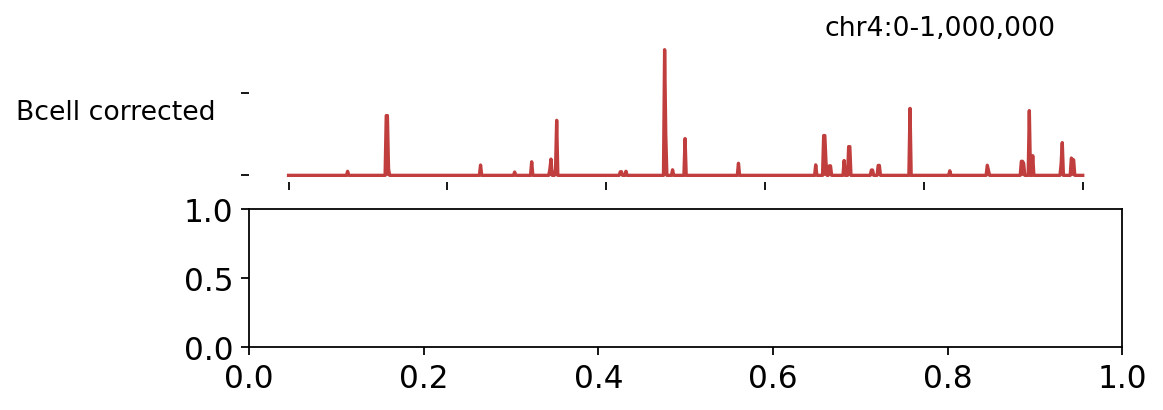

In [3]:
bw = ov.epi.bulk.bigwig({'Bcell corrected': str(OUT / 'Bcell_corrected.bw'),
                         'Tcell corrected': str(OUT / 'Tcell_corrected.bw')})
bw.read()
bw.plot_track(chrom='chr4', chromstart=0, chromend=1_000_000,
              color_dict={'Bcell corrected': '#c13e3e', 'Tcell corrected': '#3a6eb3'},
              figwidth=7, figheight=2.5, value_type='max')
plt.show()

└─ Load bigWig files
  ├─ Loading Bcell footprint...
  └─ Loading Tcell footprint...


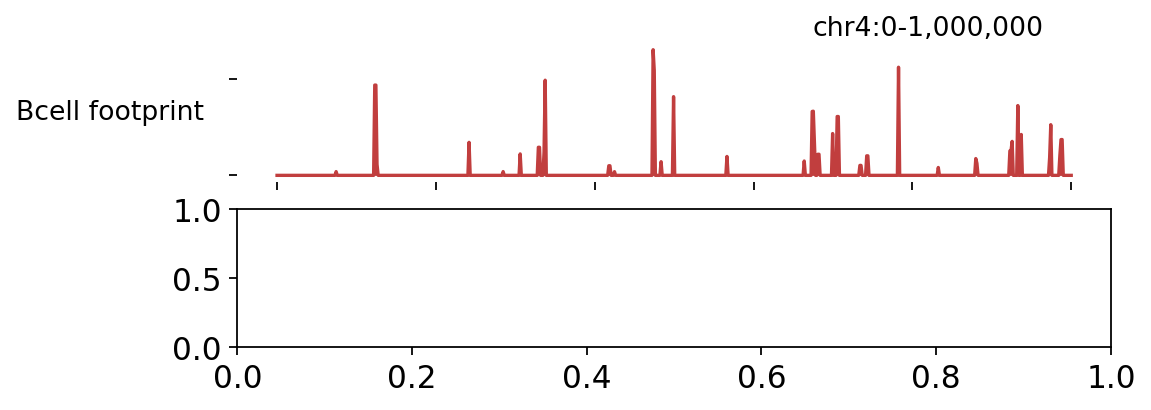

In [4]:
bw = ov.epi.bulk.bigwig({'Bcell footprint': str(DATA / 'Bcell_footprints.bw'),
                         'Tcell footprint': str(DATA / 'Tcell_footprints.bw')})
bw.read()
bw.plot_track(chrom='chr4', chromstart=0, chromend=1_000_000,
              color_dict={'Bcell footprint': '#c13e3e', 'Tcell footprint': '#3a6eb3'},
              figwidth=7, figheight=2.5, value_type='max')
plt.show()

## 3 · Differential TF binding (BINDetect)

`ov.epi.tl.bindetect` scores every JASPAR motif's footprints in each condition and tests which TFs
change most between B and T cells — the differential-binding workhorse.

In [5]:
ov.epi.tl.bindetect(
    condition_names=['Bcell', 'Tcell'],
    score_files=[str(DATA / 'Bcell_footprints.bw'), str(DATA / 'Tcell_footprints.bw')],
    motif_file=str(DATA / 'motifs.jaspar'), fasta_file=str(DATA / 'genome.fa'),
    regions_bed=str(DATA / 'merged_peaks_annotated.bed'), output_dir=str(OUT / 'bindetect'))

summary = max((OUT / 'bindetect').glob('*_results.txt'), key=lambda p: p.stat().st_size)
tab = pd.read_csv(summary, sep='\t')
cols = [c for c in tab.columns if c in {'output_prefix', 'name', 'motif_id',
        'Bcell_Tcell_change', 'Bcell_Tcell_pvalue'}]
tab[cols].sort_values('Bcell_Tcell_pvalue').head(10)

└─ Starting BINDetect analysis...


└─ Processing input data


  └─ Found 6007 regions in input peaks
      └─ Peaks have 8 columns
      └─ Peak header list: ['peak_chr', 'peak_start', 'peak_end', 'additional_1', 'additional_2', 'additional_3', 'additional_4', 'additional_5']
  └─ GC content estimated at 47.61%
  └─ Read 83 motifs
  └─ Plotting sequence logos for each motif


Creating logos:   0%|                                                                                                | 0/83 [00:00<?, ?it/s]

Creating logos:   0%|                                                                                                | 0/83 [00:00<?, ?it/s]

...

Processing TFs: 100%|███████████████████████████████████████████████████████████████████████████████████████| 83/83 [00:04<00:00, 19.60it/s]

Processing TFs: 100%|███████████████████████████████████████████████████████████████████████████████████████| 83/83 [00:04<00:00, 19.60it/s]

└─ Writing results files
└─ Creating plots


  └─ BINDetect analysis completed!


,output_prefix,name,motif_id,Bcell_Tcell_change,Bcell_Tcell_pvalue
36,IRF1_MA0050.2,IRF1,MA0050.2,0.45392,3.672490e-140
4,BATF_MA1634.1,BATF,MA1634.1,0.63654,1.073840e-133
38,JUNB_MA0490.2,JUNB,MA0490.2,0.58744,2.038320e-116
37,IRF4_MA1419.1,IRF4,MA1419.1,0.55617,3.705740e-116
57,NRF1_MA0506.1,NRF1,MA0506.1,-0.36535,1.259370e-108
3,BACH2_MA1101.2,BACH2,MA1101.2,0.49062,3.812140e-107
45,MEF2B_MA0660.1,MEF2B,MA0660.1,0.34917,1.765280e-99
44,MEF2A_MA0052.4,MEF2A,MA0052.4,0.27290,8.179300e-99
34,HNF1A_MA0046.2,HNF1A,MA0046.2,0.41346,2.565590e-98
65,RUNX2_MA0511.2,RUNX2,MA0511.2,0.32753,1.870310e-96


## 4 · Aggregate footprint at BATF sites

Averaging the corrected Tn5 signal over all **BATF** motif sites gives the classic footprint shape
— a central dip (TF protection) with flanking accessibility — and its condition difference.

[PlotAggregate] INFO: ---- Processing input ----
[PlotAggregate] INFO: Reading information from .bed-files
[PlotAggregate] STATS: COUNT BATF_all: 990 sites
[PlotAggregate] INFO: Reading signal from bigwigs
[PlotAggregate] INFO: - Reading signal from Bcell
[PlotAggregate] INFO: - Reading signal from Tcell


[PlotAggregate] INFO: Calculating aggregate signals
[PlotAggregate] INFO: ---- Plotting aggregates ----
[PlotAggregate] INFO: Setting up plotting grid
[PlotAggregate] INFO: Plotting regions BATF_all from signal Bcell
[PlotAggregate] INFO: Plotting regions BATF_all from signal Tcell
[PlotAggregate] INFO: Adjusting final details


[PlotAggregate] INFO: Saved plot to /scratch/users/steorra/analysis/omicverse_dev/guide-upstream-wt/docs/Tutorials-epigenetics/data_epi/footprint/BATF_aggregate.pdf


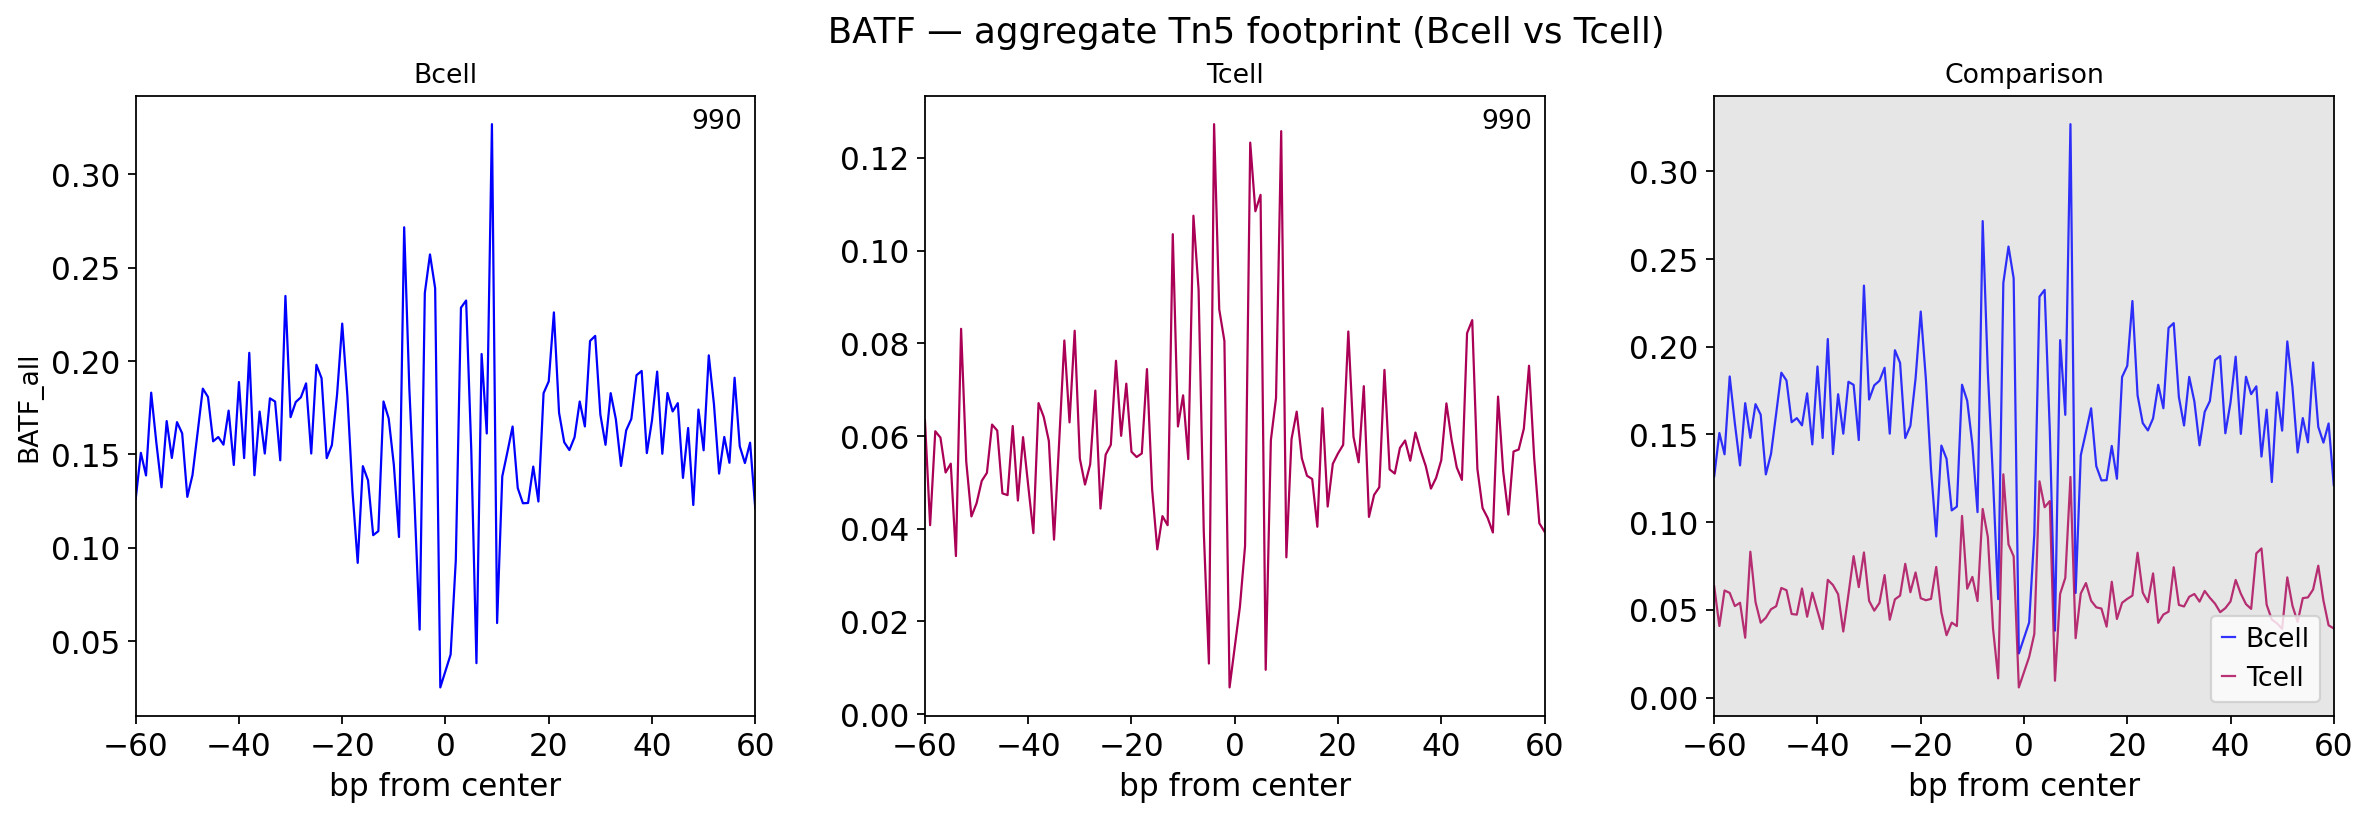

In [6]:
fig = ov.epi.tl.plot_aggregate(
    bigwig_files=[str(OUT / 'Bcell_corrected.bw'), str(OUT / 'Tcell_corrected.bw')],
    regions_bed=str(DATA / 'BATF_all.bed'), output_file=str(OUT / 'BATF_aggregate.pdf'),
    labels=['Bcell', 'Tcell'], title='BATF — aggregate Tn5 footprint (Bcell vs Tcell)')
from IPython.display import display
display(fig)

## Summary

| stage | function |
|---|---|
| Tn5 bias correction | `ov.epi.tl.atacorrect` |
| browse tracks | `ov.epi.bulk.bigwig` |
| differential TF binding | `ov.epi.tl.bindetect` |
| aggregate footprint | `ov.epi.tl.plot_aggregate` |

Footprinting reads TF occupancy directly off the Tn5 cut pattern — a bulk-ATAC complement to the
single-cell chromVAR motif-activity tutorial, and the end of the epigenetics chapter's tour from
reads (ChIP upstream) through 3D genome (Hi-C).